## SECTION 1 - BASICS ##

## Basic Functions ## 

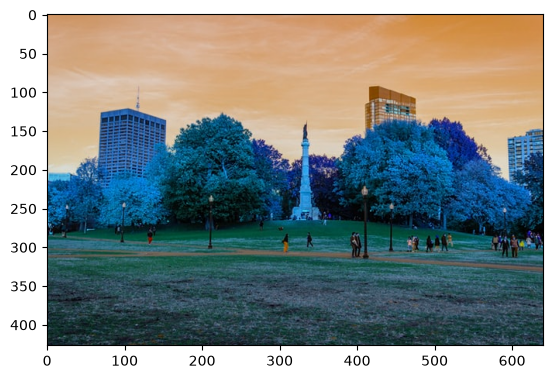

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
# Read in an image
img = cv.imread('Resources/Photos/park.jpg')
plt.imshow(img)

імпортуємо бібліотеку cv2, через метод cv.imread() визначаємо шлях до зображення, через cv.imshow() визначаємо назву вікна і саму змінну (для відкриття зображень буду використовувати matplotlib)

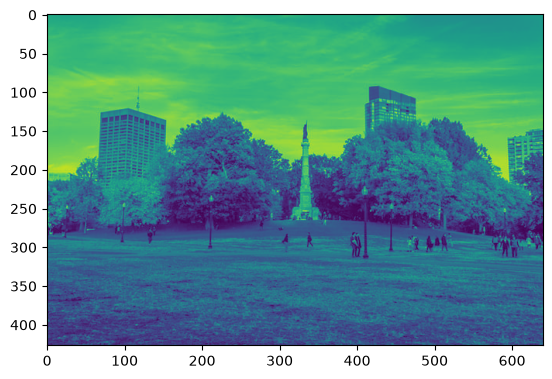

In [3]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray)

через cv.cvtColor() визначаємо змінну і через cv.COLOR_BGR2GRAY міняємо 3 канали на зображені до 1 каналу gray

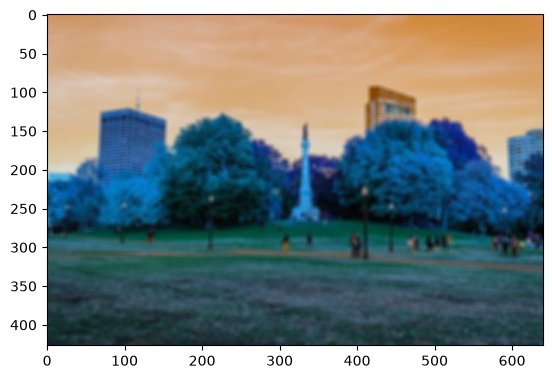

In [4]:
blur = cv.GaussianBlur(img, (7,7), cv.BORDER_DEFAULT)
plt.imshow(blur)

метод cv.GaussianBlur() виконує блюр використовуючи Gaussian filter, cv.BORDER_DEFAULT = 4 використовується для екстраполяції пікселів на зображенні, (7,7) це kernel_size (ядро згортки)

в torchvision цей метод: torchvision.transforms.GaussianBlur() / в albumentations: A.GaussianBlur. різниця в randomness в opencv фіксоване значення, в двох цих це range.

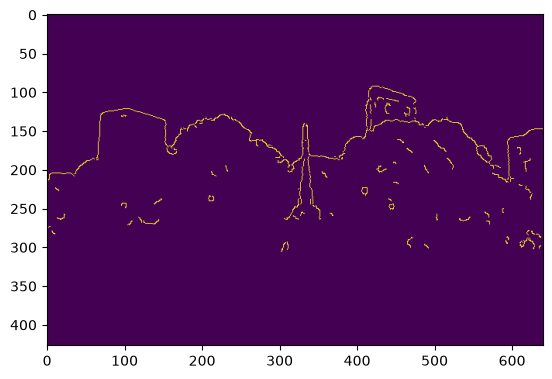

In [5]:
canny = cv.Canny(blur, 125, 175)
plt.imshow(canny)

через cv.Canny() можемо визначати края обʼєктів на зображенні, 125 і 175 це thresholds (низкий поріг (для слабких звʼязків) і високий (для сильних звʼязків))

в torchvision & albumentations(cv.Canny): логіка алгоритму така сама, різниця тільки в можливості hardware і підтримки батчів

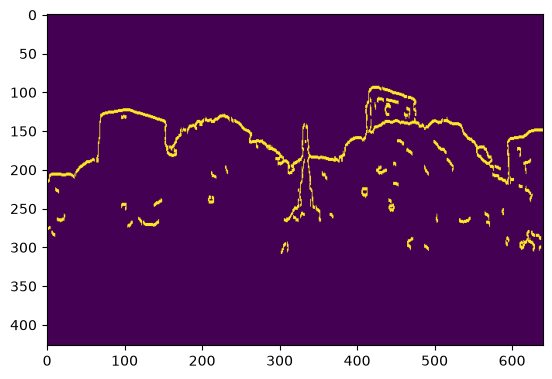

In [6]:
dilated = cv.dilate(canny, (7,7), iterations=3)
plt.imshow(dilated)

через метод cv.dilate() ми можемо розширювати білі регіони зображення (потовщуємо), визначаємо kernel_size, iterations=3 означає кількість ітерацій операції.

torchvision & albumentations(cv.dilate): random augmentation pipeline / batch tensor, коли в opencv це просто зображення.

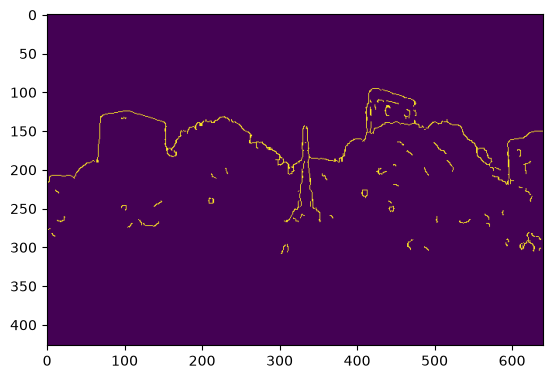

In [7]:
eroded = cv.erode(dilated, (7,7), iterations=3)
plt.imshow(eroded)

cv.erode() навпаки зменшує білі регіони на зображенні.

torchvision & albumentations: таке саме як і для cv.dilate()

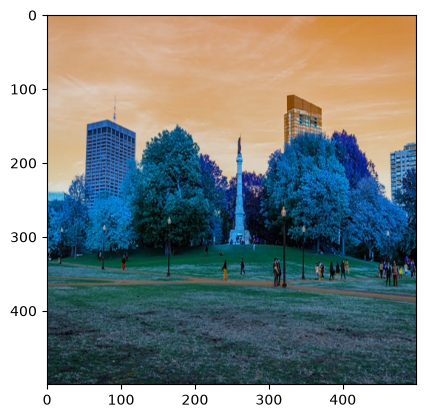

In [8]:
resized = cv.resize(img, (500,500), interpolation=cv.INTER_CUBIC)
plt.imshow(resized)

метод cv.resize() змінює dimensions для вхідного зображення, interpolation в цьому методі із значенням INTER_CUBIC означає метод інтерполяції для зображення - INTER_CUBIC для повільнішої, але якість буде найкраща.

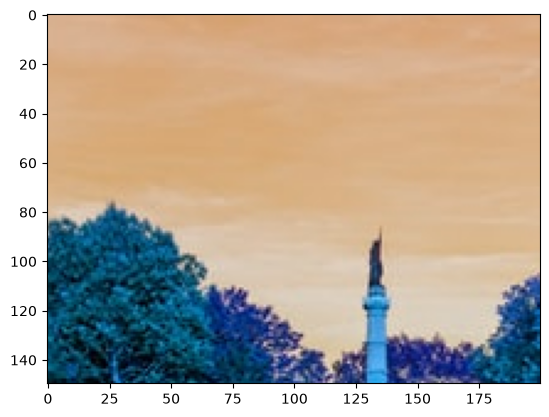

In [9]:
cropped = img[50:200, 200:400]
plt.imshow(cropped)

numpy синтаксис для слайсінгу зображень, де перше значення це вертикальне, а друге це горизонтальне.

## Contours ##

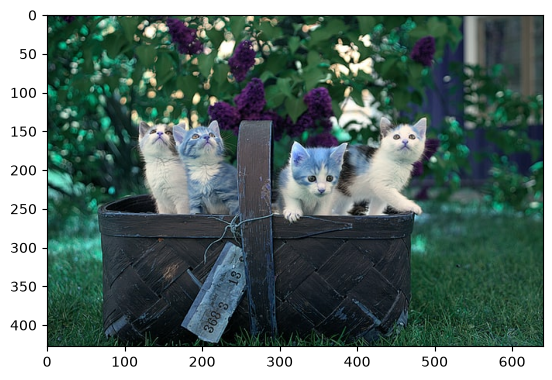

In [10]:
img = cv.imread('Resources/Photos/cats.jpg')
plt.imshow(img)

просто відкриваємо зображення за його шляхом.

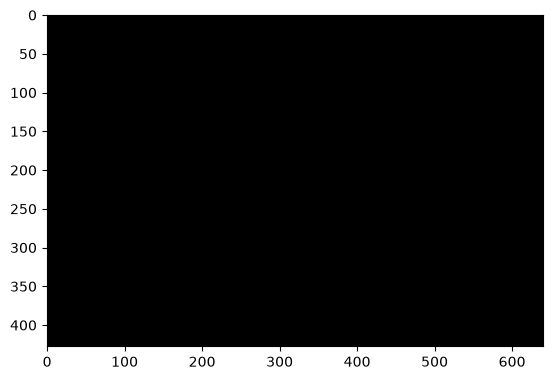

In [11]:
import numpy as np
blank = np.zeros(img.shape, dtype='uint8')
plt.imshow(blank)

через numpy метод для створення масиву з нулів отримуємо "пусте" зображення (суцільно чорне)

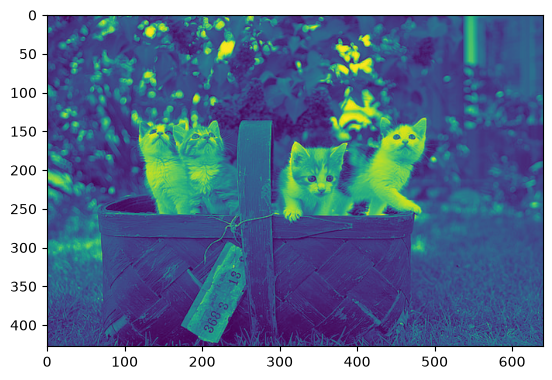

In [12]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray)

конвертуємо зображення в gray вигляд

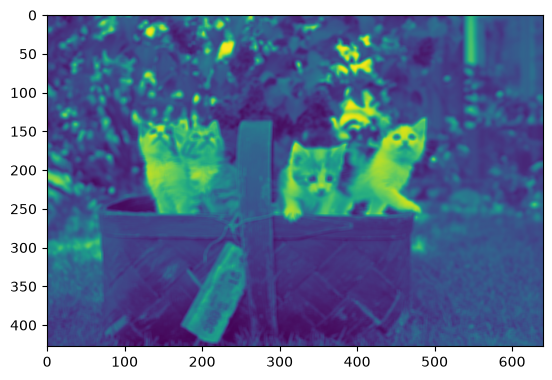

In [13]:
blur = cv.GaussianBlur(gray, (5,5), cv.BORDER_DEFAULT)
plt.imshow(blur)

повторюємо метод для накладання на зображення гаусівського блюру

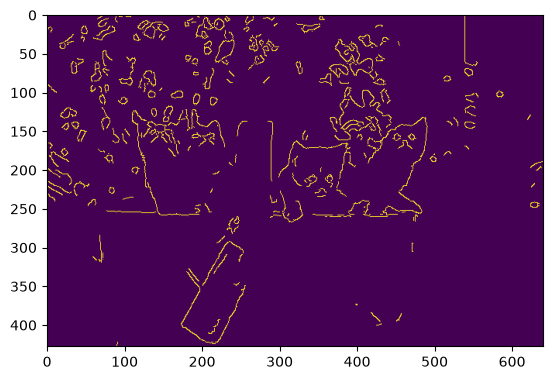

In [14]:
canny = cv.Canny(blur, 125, 175)
plt.imshow(canny)

наведення країв обʼєктів на зображенні білим кольором

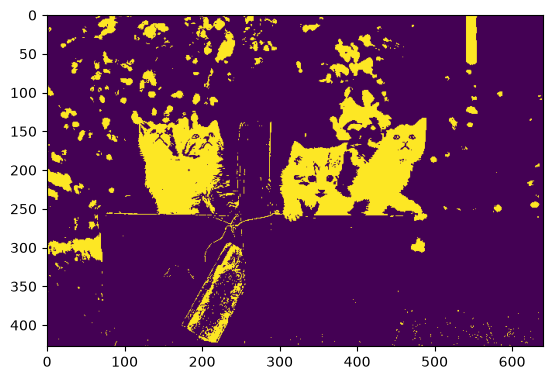

In [15]:
ret, thresh = cv.threshold(gray, 125, 255, cv.THRESH_BINARY)
plt.imshow(thresh)

метод cv.threshold() конвертує зображення до black/white формату (THRESH_BINARY), з певними значеннями для нижнього і верхнього порогів 

380 contour(s) found!


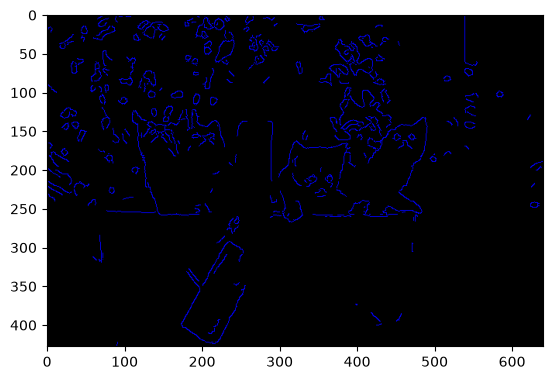

In [16]:
contours, hierarchies = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(f'{len(contours)} contour(s) found!')

cv.drawContours(blank, contours, -1, (0,0,255), 1)
plt.imshow(blank)

метод cv.findCountours() знаходить контури з binary/edge зображень, cv.RETR_LIST означає повернення усіх контурів зображення, cv.CHAIN_APPROX_SIMPLE стискає контури (прибирає залишкові точки). метод cv.drawContours() малює на "пустому" зображенні до цього контури (список контурів, "contours"), "-1" означає намалювати усі контури, або можна написати інший індекс для окремого контура. в скобках це палітра кольорів від 0 до 255 в BGR форматі (але через те, що я відмальовую зображення через matplotlib, то воно презентує це у форматі RGB)

## Draw ##

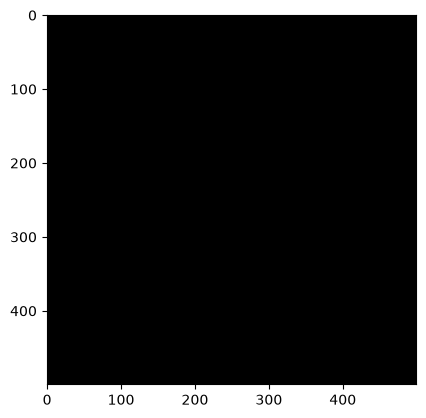

In [19]:
blank = np.zeros((500,500,3), dtype='uint8')
plt.imshow(blank)

створюємо масив з нулів і виводимо через imshow()

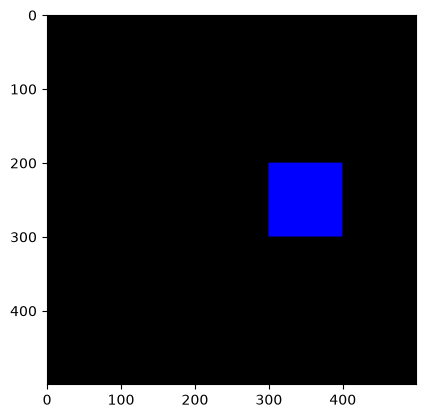

In [20]:
blank[200:300, 300:400] = 0,0,255
plt.imshow(blank)

через синтаксис слайсінгу визначаємо квадрат і колір для нього у форматі BGR

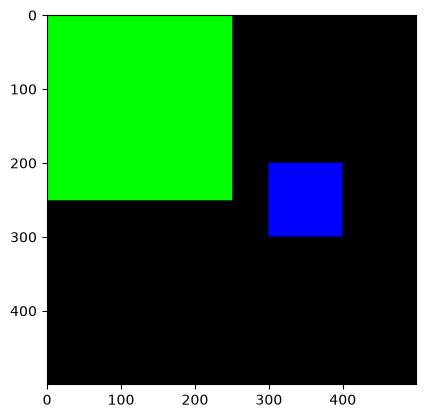

In [21]:
cv.rectangle(blank, (0,0), (blank.shape[1]//2, blank.shape[0]//2), (0,255,0), thickness=-1)
plt.imshow(blank)

через метод cv.rectangle() можемо малювати квадрат, де перше значення в методі це координати верхньої точки, а друге це координати нижньої точки, далі колір і thickness=-1 означає, що квадрат повинен бути заповненим.

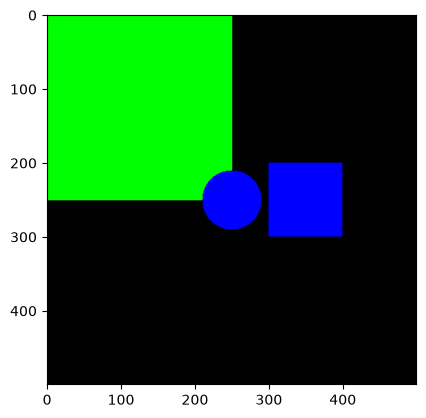

In [22]:
cv.circle(blank, (blank.shape[1]//2, blank.shape[0]//2), 40, (0,0,255), thickness=-1)
plt.imshow(blank)

через метод cv.circle() додаємо до нашого зображення коло: значення координат центру кола, далі радіус, колір і thickness

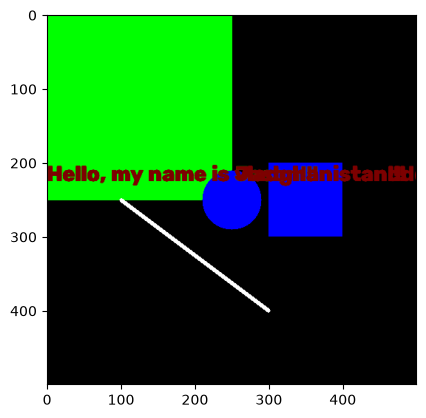

In [32]:
cv.line(blank, (100,250), (300,400), (255,255,255), thickness=3)
plt.imshow(blank)

через метод cv.line() можна на зображенні додати лінію через дві координати та колір і thickness.

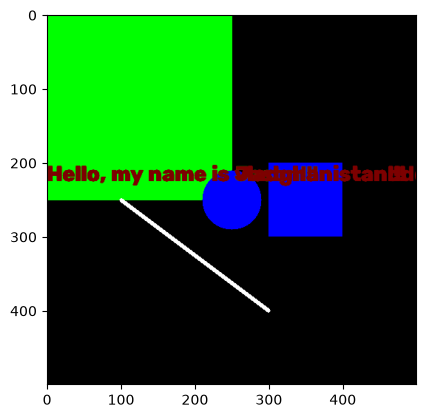

In [33]:
cv.putText(blank, 'Hello, my name is vladghanistan!!!', (0,225), cv.FONT_HERSHEY_TRIPLEX, 1.0, (125,0,0), 2)
plt.imshow(blank)

через метод cv.putText() можна додавати текст на зображення: string який потрібно вивести, координати, fontFace: cv.FONT_HERSHEY_TRIPLEX, fontScale 1.0, колір і товщина '2'.

## Read ##

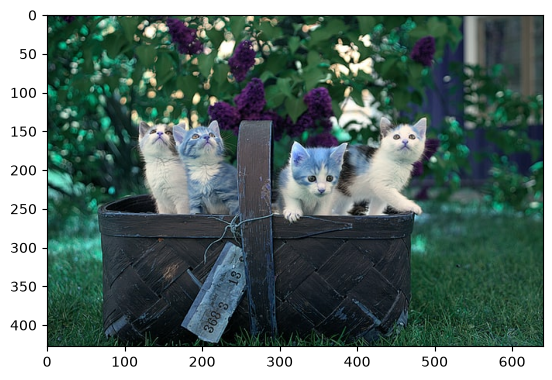

In [34]:
img = cv.imread('Resources/Photos/cats.jpg')
plt.imshow(img)


In [5]:
import cv2 as cv
import matplotlib.pyplot as plt
capture = cv.VideoCapture('Resources/Videos/dog.mp4')

while True:
    isTrue, frame = capture.read()
    
    # if cv.waitKey(20) & 0xFF==ord('d'):
    # This is the preferred way - if `isTrue` is false (the frame could 
    # not be read, or we're at the end of the video), we immediately
    # break from the loop. 
    if isTrue:    
        cv.imshow('Video',frame)
        if cv.waitKey(20) & 0xFF==ord('d'):
            break            
    else:
        break

capture.release()
cv.destroyAllWindows()

через метод cv.VideoCapture() із вказанням шляху до відео описуємо цикл в якому ми відтворюємо відео, якщо isTrue стає False, то ми виходимо з циклу.

torchvision & albumentations(cv.VideoCapture): .mp4;.avi файли, вихід через tensor / немає підтримки для відтворення відеофайлів

## Thresh ##

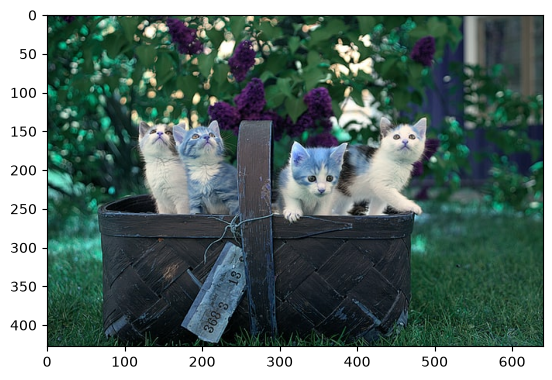

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
img = cv.imread('Resources/Photos/cats.jpg')
plt.imshow(img)

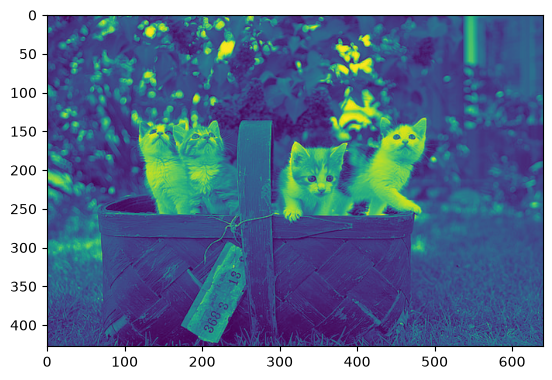

In [4]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray)

конвертуємо до gray формату (в matplotlib воно не black/white, а green-yellow-purple, якщо не вказувати аргумент cmap)

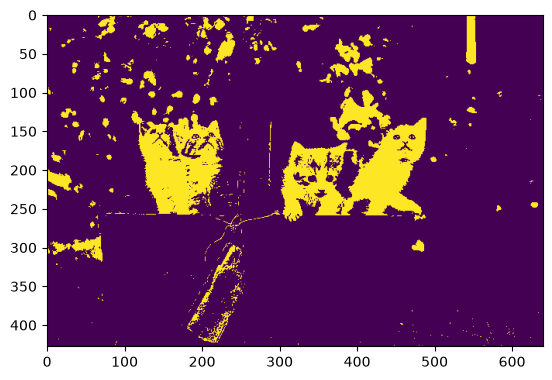

In [25]:
threshold, thresh = cv.threshold(gray, 140, 255, cv.THRESH_BINARY )
plt.imshow(thresh)

за допомогою cv.threshold() перетворюється зображення до binary вигляду із використанням порогових значень (140, 255), тобто пікселі з інтенсивністю 140 і більше становляться білого кольору, а ті що нижче 140 становляться чорними, cv.THRESH_BINARY означає, що усі пікселі що нижче 140 становляться black.

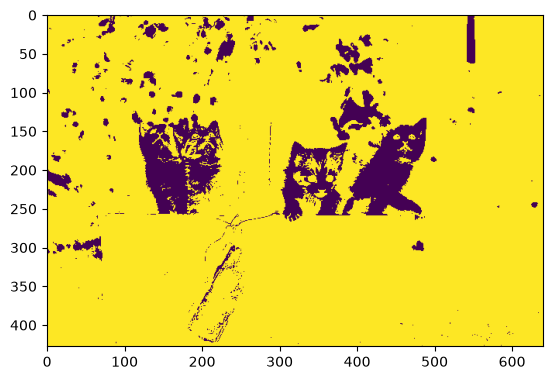

In [26]:
threshold, thresh_inv = cv.threshold(gray, 150, 255, cv.THRESH_BINARY_INV )
plt.imshow(thresh_inv)

логіка така сама що і в попередньому завданні, єдине що відрізняється це threshold type cv.THRESH_BINARY_INV, що означає інвертоване значення до cv.THRESH_BINARY, тобто усі значення що вище 140 становлятся black, а що нижче то white.

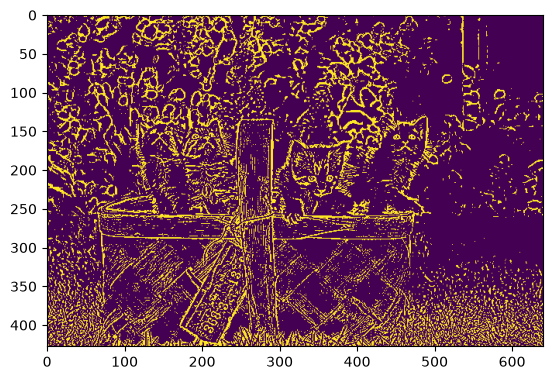

In [27]:
adaptive_thresh = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, 11, 9)
plt.imshow(adaptive_thresh)

cv.adaptiveThreshold() виконує адаптивне перетворення зображення за пороговими значеннями по регіонам, 255 це максимальне значення для пікселів, що вище порогу, cv.ADAPTIVE_THRESH_GAUSSIAN_C, означає, що використовується гаусівська сума, cv.THRESH_BINARY_INV інвертує значення до cv.THRESH_BINARY, 11 це розмір сусіднього блока, 9 це значення, яке повинно відніматися від середнього значення сусіднього блока (11х11)

torchvision & albumentations (cv.adaptiveThreshold): підтримка батчів, тип тензор / така сама логіка як і для opencv.

## Transformations ##

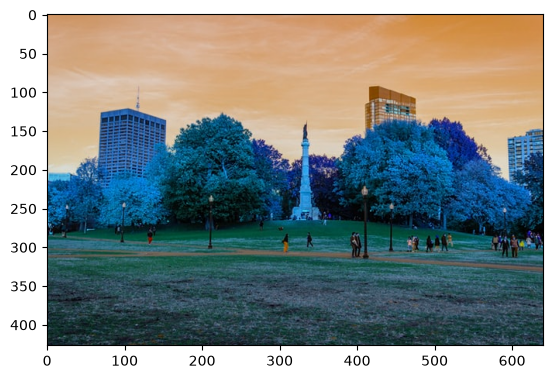

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
img = cv.imread('Resources/Photos/park.jpg')
plt.imshow(img)

виводимо зображення

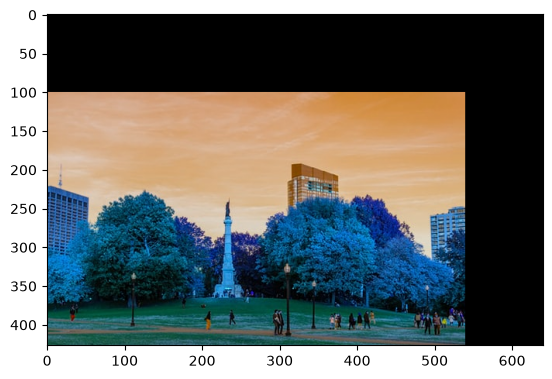

In [4]:
import numpy as np
def translate(img, x, y):
    transMat = np.float32([[1,0,x],[0,1,y]])
    dimensions = (img.shape[1], img.shape[0])
    return cv.warpAffine(img, transMat, dimensions)

translated = translate(img, -100, 100)
plt.imshow(translated)

через функцію створюємо матрицю (2х3) через np.float32(), далі визначаємо output висоту та ширину і повертаємо метод cv.warpAffine() афінної трансформації для зображення, далі створюємо змінну де через translate() викликаємо функцію, де аргументи такі: координати зображення на зображенні img, де координати виглядають таким чином, що відʼємні значення це вліво та вгору по x,y відповідно, а плюсові значення це вправо та вниз, x,y, відповідно.

torchvision & albumentations (cv.warpAffine): (на відміну від обох бібліотек, логіка цього методу в opencv виконується ручними обрахунками, коли в torchvision & albumentations це все автоматично) тензори + підтримка батчів / маски та бокси.

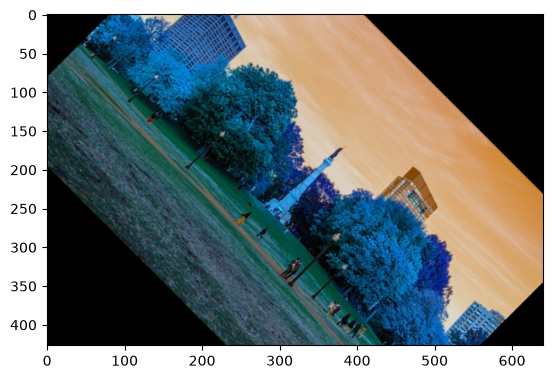

In [5]:
def rotate(img, angle, rotPoint=None):
    (height,width) = img.shape[:2]

    if rotPoint is None:
        rotPoint = (width//2,height//2)
    
    rotMat = cv.getRotationMatrix2D(rotPoint, angle, 1.0)
    dimensions = (width,height)

    return cv.warpAffine(img, rotMat, dimensions)

rotated = rotate(img, -45)
plt.imshow(rotated)

створюємо функцію де визначаємо висоту та ширину = .shape нашого зображення, якщо немає значення для центру rotation, то висота та ширина ділиться навпіл і це буде поінтом для центру rotation, далі визначаємо cv.getRotationMatrix2D(), через який створюється матриця із центром (rotPoint), кутом повороту і scaling factor = 1.0, означає, що без масштабування, через cv.warpAffine() виконуємо афінне перетворення за значенням зображення, матриці rotation, і за значенням висоти та ширини зображення.

torchvision & albumentations: (на відміну від двох бібліотек, в opencv присутній output matrix для cv.getRotationMatrix2D, а в бібліотеках ні) використовується тензор

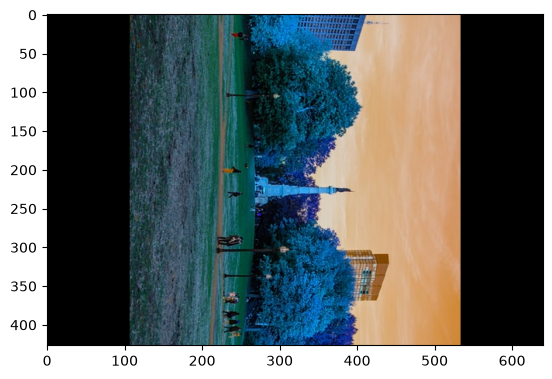

In [6]:
rotated_rotated = rotate(img, -90)
plt.imshow(rotated_rotated)

через функцію rotate() повертаємо зображення на 90 градусів

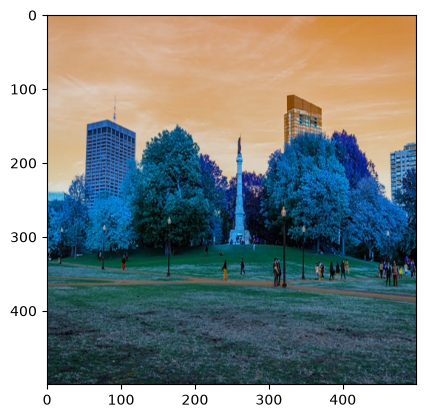

In [7]:
resized = cv.resize(img, (500,500), interpolation=cv.INTER_CUBIC)
plt.imshow(resized)

через метод cv.resize() для зображення виначаємо його границі по x,y і спосіб інтерполяції (повільніший за інші, але найкращий для якості зображення)

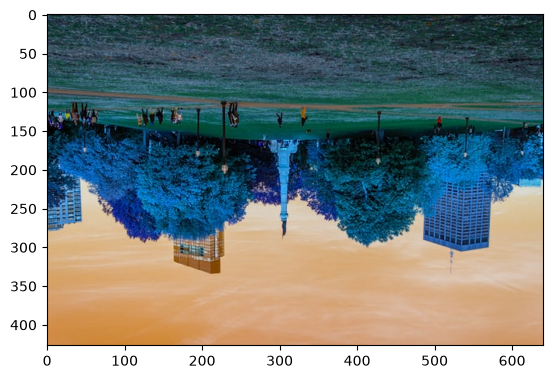

In [8]:
flip = cv.flip(img, -1)
plt.imshow(flip)

через метод cv.flip() фліпаємо зображення, значненя для фліпу такі, що якщо "1", то це фліп по горизонталі, якщо "0", то це фліп по вертикалі, а якщо "-1" як в цьому випадку, то фліп йде по вертикалі і горизонталі одночасно

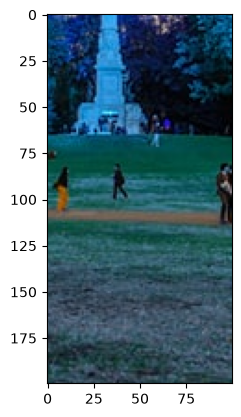

In [9]:
cropped = img[200:400, 300:400]
plt.imshow(cropped)

через слайсінг виконуємо обріз зображення

## SECTION 2 - ADVANCED ##

## Bitwise ##

In [10]:
blank = np.zeros((400,400), dtype='uint8')

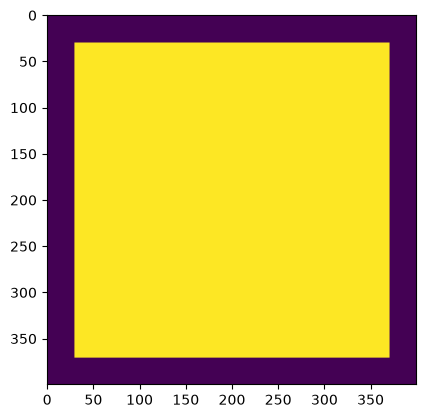

In [15]:
rectangle = cv.rectangle(blank.copy(), (30,30), (370,370), 255, -1)
circle = cv.circle(blank.copy(), (200,200), 200, 255, -1)

plt.imshow(rectangle)


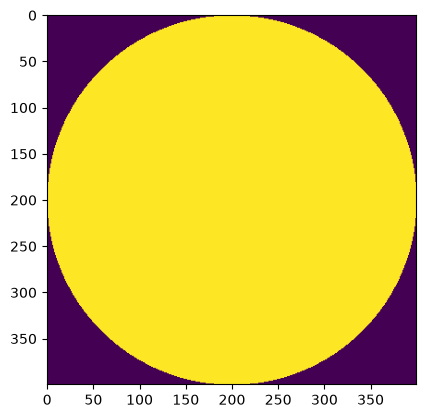

In [14]:
plt.imshow(circle)

через два методи створюється прямокутник та коло, (blank.copy() копіє оригінал), визначаються дві точки для прямокутника, колір (255, білий) і заповненість (-1),
для кола теж копіюється оригінал, обирається точка для центру кола, колір і заповненість

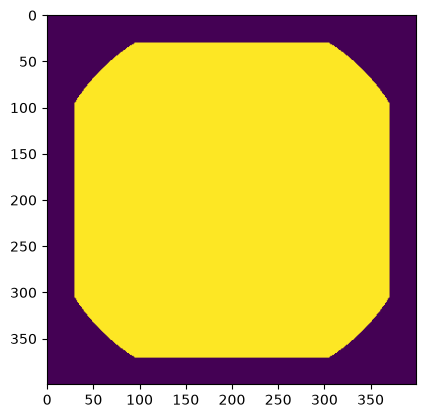

In [12]:
bitwise_and = cv.bitwise_and(rectangle, circle)
plt.imshow(bitwise_and)

метод cv.bitwise_and() виконує операцію побітового AND = тобто там де пересікаються білі регіони (255) між двома обʼєктами там і буде білий колір, якщо ні, то там буде чорний

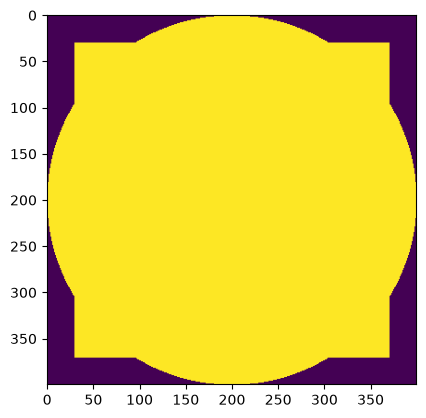

In [13]:
bitwise_or = cv.bitwise_or(rectangle, circle)
plt.imshow(bitwise_or)

через метод cv.bitwise_or() ми робимо побітове OR для двох обʼєктів = тобто, вони відображаються разом накладаючись

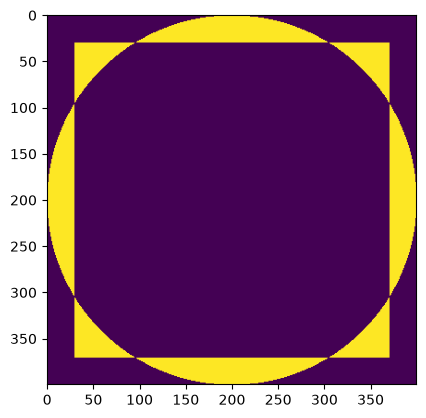

In [16]:
bitwise_xor = cv.bitwise_xor(rectangle, circle)
plt.imshow(bitwise_xor)

через метод cv.bitwise_xor() робимо XOR = тобто там, де вони пересікаються буде чорним, а там де вони не пересікаються - незмінні і відображаються

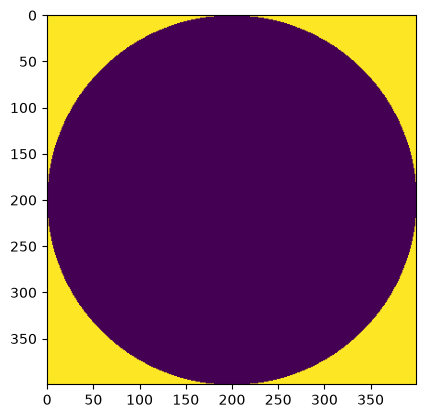

In [17]:
bitwise_not = cv.bitwise_not(circle)
plt.imshow(bitwise_not)

через метод cv.bitwise_not() для кола ми інвертуємо його значення - він стає чорним, а фон стає білим.

## Blurring ##

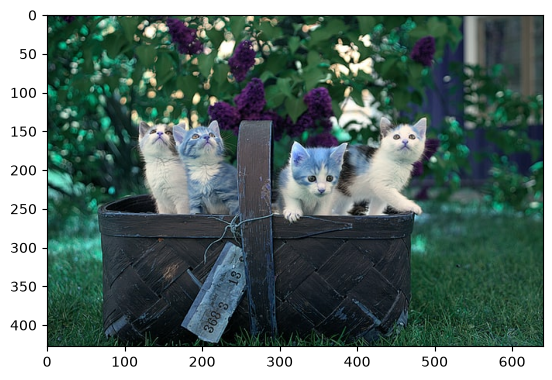

In [18]:
img = cv.imread('Resources/Photos/cats.jpg')
plt.imshow(img)

виводимо зображення

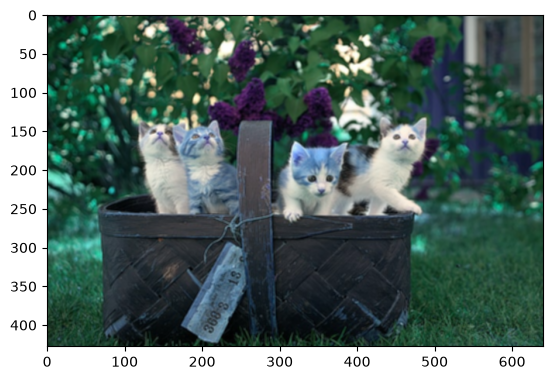

In [19]:
average = cv.blur(img, (3,3))
plt.imshow(average)

використовуємо метод cv.blur() до зображення з kernel_window (3x3), чим більше kernel_window ти сильніше блюр, якщо менше - менше блюру

torchvision & albumentations(cv.blur): (стохастичне виконання блюру в обох бібліотеках) + функціональне

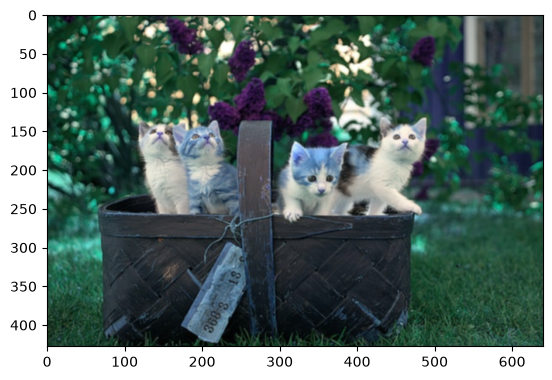

In [20]:
gauss = cv.GaussianBlur(img, (3,3), 0)
plt.imshow(gauss)

через метод cv.GaussianBlur() виконуємо блюр з використанням гаусівського фільтру з kernel_window (3x3), 0 це sigma = (стандартне відхилення гаусівського ядра), чим більше значення, тим ширше розмиття і сильніше згладжування, чим менше значення, тим вужче розмиття і слабше згладжування

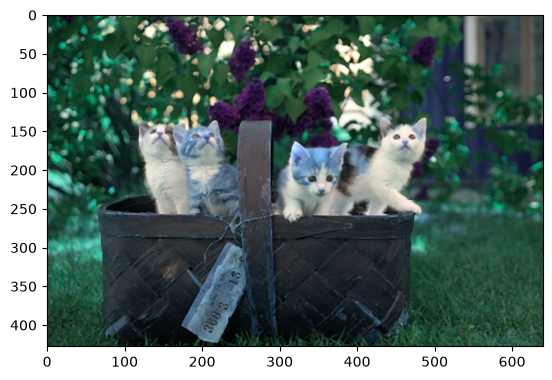

In [21]:
median = cv.medianBlur(img, 3)
plt.imshow(median)

через метод cv.medianBlur() виконується блюр по kernel_window (3x3) розміру і застосовує медіанний фільтр для блюра

torchvision & albumentations(cv.medianBlur): немає в цій бібліотеці, є тільки в native pytorch / стиль виконання стохастичний (рандомізований)

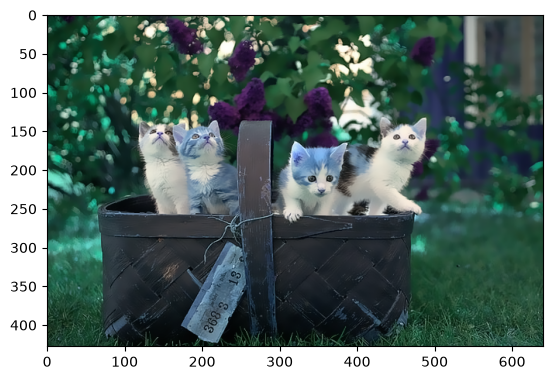

In [22]:
bilateral = cv.bilateralFilter(img, 10, 35, 25)
plt.imshow(bilateral)

метод cv.bilateralFilter() застосовує два гаусівських kernel і робить розмиття (виключачи edges обʼєктів), "10" це діаметр сусідних пікселів, "35" це sigma для кольорової різниці, а "25" це sigma значення просторової відстані

torchvision & albumentations(cv.bilateralFilter): немає такого аналогу, є тільки в нативному pytorch / стохастичне виконання